# Семинар 5: разметка изображений с помощью VLM

Этот ноутбук размечает все изображения из папки `./data` с помощью модели `HuggingFaceTB/SmolVLM-256M-Instruct`.

Пояснения, комментарии и выводы написаны на русском языке. Сам промпт для модели оставлен на английском, потому что для SmolVLM в задании указано использовать английские промпты. Ноутбук требует CUDA и явно переносит модель и входные тензоры на GPU.

In [1]:
# Install missing packages into the current Jupyter kernel.
# The first run can take time because Python packages and model weights are downloaded.
import importlib.util
import os
import subprocess
import sys

# Hugging Face Xet can hang on Windows at 0 percent in some environments.
# Disable it before importing transformers or huggingface_hub.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "0")

REQUIRED_PACKAGES = {
    "PIL": "pillow",
    "torch": "torch",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "safetensors": "safetensors",
    "sentencepiece": "sentencepiece",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])
else:
    print("All required packages are installed.")

print("HF_HUB_DISABLE_XET =", os.environ.get("HF_HUB_DISABLE_XET"))


All required packages are installed.
HF_HUB_DISABLE_XET = 1


In [2]:
import os
from pathlib import Path
import csv
import json
import time

# Set these again in case the notebook is not executed from the first cell.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "0")

from PIL import Image
import torch
from transformers import AutoProcessor

try:
    from transformers import AutoModelForImageTextToText as VLMModel
except ImportError:
    from transformers import AutoModelForVision2Seq as VLMModel

DATA_DIR = Path("data")
OUTPUT_JSONL = Path("labels_smolvlm.jsonl")
OUTPUT_CSV = Path("labels_smolvlm.csv")
MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"
MODEL_CACHE_DIR = Path("models")

# After a successful first download, set this to True to load strictly from local cache.
LOCAL_FILES_ONLY = False

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MAX_NEW_TOKENS = 96

assert DATA_DIR.is_dir(), f"Dataset directory not found: {DATA_DIR.resolve()}"
assert torch.cuda.is_available(), "CUDA is not available. Run this notebook in a GPU environment."

DEVICE = torch.device("cuda:0")
DEVICE_MAP = {"": "cuda:0"}
DTYPE = torch.float16

print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Dataset directory:", DATA_DIR.resolve())
print("Model cache directory:", MODEL_CACHE_DIR.resolve())
print("JSONL output:", OUTPUT_JSONL.resolve())
print("CSV output:", OUTPUT_CSV.resolve())


c:\anacon\envs\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cu126
CUDA version: 12.6
GPU: NVIDIA GeForce GTX 1650 Ti
Dataset directory: C:\python\try_to_nn\CV_ITMO\sem_5\data
Model cache directory: C:\python\try_to_nn\CV_ITMO\sem_5\models
JSONL output: C:\python\try_to_nn\CV_ITMO\sem_5\labels_smolvlm.jsonl
CSV output: C:\python\try_to_nn\CV_ITMO\sem_5\labels_smolvlm.csv


Найдено изображений: 174


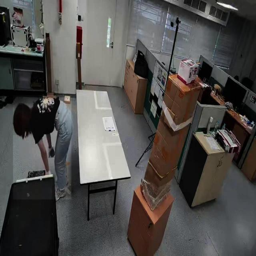

Пример файла: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg (640, 640)


In [3]:
image_paths = sorted(p for p in DATA_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
print(f"Найдено изображений: {len(image_paths)}")

if not image_paths:
    raise RuntimeError(f"В папке {DATA_DIR.resolve()} не найдено изображений")

sample_image = Image.open(image_paths[0]).convert("RGB")
display(sample_image.resize((256, 256)))
print("Пример файла:", image_paths[0].name, sample_image.size)


In [4]:
print("Loading processor from Hugging Face or local cache...")
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    cache_dir=MODEL_CACHE_DIR,
    local_files_only=LOCAL_FILES_ONLY,
)

print("Loading model directly on GPU...")
try:
    model = VLMModel.from_pretrained(
        MODEL_ID,
        cache_dir=MODEL_CACHE_DIR,
        local_files_only=LOCAL_FILES_ONLY,
        dtype=DTYPE,
        low_cpu_mem_usage=True,
        device_map=DEVICE_MAP,
    )
except TypeError:
    # Fallback for older transformers versions that do not support dtype yet.
    model = VLMModel.from_pretrained(
        MODEL_ID,
        cache_dir=MODEL_CACHE_DIR,
        local_files_only=LOCAL_FILES_ONLY,
        torch_dtype=DTYPE,
        low_cpu_mem_usage=True,
    ).to(DEVICE)

tokenizer = getattr(processor, "tokenizer", None)
text_config = getattr(model.config, "text_config", None)
vocab_size = getattr(text_config, "vocab_size", None) or getattr(model.config, "vocab_size", None)

if tokenizer is not None:
    candidates = [tokenizer.pad_token_id, tokenizer.eos_token_id]
    safe_pad_token_id = next(
        (
            token_id
            for token_id in candidates
            if isinstance(token_id, int) and (vocab_size is None or 0 <= token_id < vocab_size)
        ),
        None,
    )
    if safe_pad_token_id is not None:
        model.config.pad_token_id = safe_pad_token_id
        model.generation_config.pad_token_id = safe_pad_token_id

model.eval()
model_device = next(model.parameters()).device
assert model_device.type == "cuda", f"Model is not loaded on GPU: {model_device}"
print("Model loaded on device:", model_device)


Loading processor from Hugging Face or local cache...


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading model directly on GPU...


Loading weights: 100%|██████████| 471/471 [00:00<00:00, 1838.27it/s]


Model loaded on device: cuda:0


In [5]:
# Промпт оставлен на английском языке: это требование для SmolVLM из условия задания.
PROMPT = """Describe this image for a computer vision dataset.
Return one concise sentence in English.
Include the main visible objects, scene, actions if any, colors, and important context.
Do not invent hidden details. Do not use bullet points."""


def build_inputs(image: Image.Image, prompt: str):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    text = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=text, images=[image], return_tensors="pt")
    return inputs.to(DEVICE)


def generate_caption(image_path: Path, prompt: str = PROMPT) -> str:
    image = Image.open(image_path).convert("RGB")
    inputs = build_inputs(image, prompt)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
        )

    prompt_length = inputs["input_ids"].shape[1]
    generated_ids = generated_ids[:, prompt_length:]
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    return " ".join(caption.split())


In [6]:
# Быстрая проверка на одном изображении перед запуском разметки всего датасета.
test_caption = generate_caption(image_paths[0])
print(image_paths[0].name)
print(test_caption)


-01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
Computer vision dataset.


In [7]:
def load_done_items(path: Path) -> dict:
    """Загружает уже размеченные изображения, чтобы можно было продолжить после прерывания."""
    if not path.exists():
        return {}

    items = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            items[item["file_name"]] = item
    return items


def append_jsonl(path: Path, item: dict) -> None:
    """Сохраняет одну запись сразу после генерации подписи."""
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")


done_items = load_done_items(OUTPUT_JSONL)
print(f"Уже размечено: {len(done_items)} / {len(image_paths)}")

start = time.time()
for idx, image_path in enumerate(image_paths, start=1):
    if image_path.name in done_items:
        continue

    caption = generate_caption(image_path)
    item = {
        "file_name": image_path.name,
        "image_path": str(image_path.as_posix()),
        "caption": caption,
        "model": MODEL_ID,
        "prompt": PROMPT,
    }
    append_jsonl(OUTPUT_JSONL, item)
    done_items[image_path.name] = item

    if idx % 10 == 0 or idx == len(image_paths):
        elapsed = time.time() - start
        print(f"Обработано {idx}/{len(image_paths)}, прошло {elapsed:.1f} сек.")
        torch.cuda.empty_cache()

print(f"Готово. Размечено изображений: {len(done_items)}")


Уже размечено: 0 / 174
Обработано 10/174, прошло 103.1 сек.
Обработано 20/174, прошло 201.7 сек.
Обработано 30/174, прошло 300.2 сек.
Обработано 40/174, прошло 407.9 сек.
Обработано 50/174, прошло 504.2 сек.
Обработано 60/174, прошло 610.9 сек.
Обработано 70/174, прошло 718.4 сек.
Обработано 80/174, прошло 827.2 сек.
Обработано 90/174, прошло 941.0 сек.
Обработано 100/174, прошло 1058.9 сек.
Обработано 110/174, прошло 1173.3 сек.
Обработано 120/174, прошло 1278.3 сек.
Обработано 130/174, прошло 1390.6 сек.
Обработано 140/174, прошло 1501.2 сек.
Обработано 150/174, прошло 1612.0 сек.
Обработано 160/174, прошло 1724.3 сек.
Обработано 170/174, прошло 1828.7 сек.
Обработано 174/174, прошло 1872.3 сек.
Готово. Размечено изображений: 174


In [8]:
items = [done_items[name] for name in sorted(done_items)]

with OUTPUT_CSV.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file_name", "image_path", "caption", "model", "prompt"])
    writer.writeheader()
    writer.writerows(items)

print(f"JSONL сохранен: {OUTPUT_JSONL.resolve()}")
print(f"CSV сохранен: {OUTPUT_CSV.resolve()}")
print("Первые записи:")
for item in items[:5]:
    print("-", item["file_name"], "=>", item["caption"])


JSONL сохранен: C:\python\try_to_nn\CV_ITMO\sem_5\labels_smolvlm.jsonl
CSV сохранен: C:\python\try_to_nn\CV_ITMO\sem_5\labels_smolvlm.csv
Первые записи:
- -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg => Computer vision dataset.
- -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg => Room full of boxes stacked in a way that looks like a tower.
- -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg => This image depicts a scene within a computer vision lab. The focal point is a large, cardboard box prominently displayed in the foreground. The box is labeled with the brand name "FLOWER" and features a graphic of a flower. The box is secured with a metal band around its edges, indicating that it is intended for use in a computer-aided design (CAD) or computer-aided manufacturing (CAM) system. In the background, there are several
- -01-16-2-4-2-1-28_jpg.rf.ebeb8cf9d541d5af713ac4414162e366.jpg => The woman is looking at a box. She is standing in front of 